# Animal Detection in Camera Trap Images

**Project stage:** Project Topic Meeting  
**Task type:** Object Detection  

## Team Members
- Kamila Korczyńska
- Kamil Tasarz


## Project Overview

This project focuses on **animal detection in camera trap images**. The main goal is to localize animals with one or more bounding boxes.

## Problem Definition

We define the project as an **object detection** task.

Let the dataset be denoted by

$\mathcal{D} = \{(I_i, Y_i)\}_{i=1}^{N}$,

where:
- $I_i \in \mathbb{R}^{H \times W \times C}$ is a camera trap image,
- $Y_i = \{(b_{ij}, \ell_{ij})\}_{j=1}^{M_i}$ is the set of annotated objects in the image,
- $b_{ij} = (x_{ij}, y_{ij}, w_{ij}, h_{ij})$ denotes a bounding box, for example by its top-left corner and box width and height,
- $\ell_{ij}$ is the corresponding object label.

The number of objects $M_i$ may vary between images. In the current ENA24 setup used for this project, images are expected to contain at least one annotated animal, so the practical focus is on:
- $M_i = 1$ for images with a single visible animal,
- $M_i > 1$ for images containing multiple animals.

**Input:** one camera trap image  
**Output:** a set of predicted bounding boxes and labels  
**Goal:** learn a function

$f : \mathbb{R}^{H \times W \times C} \rightarrow \{(\hat{b}_k, \hat{\ell}_k)\}_{k=1}^{\hat{M}}$

that predicts the locations and labels of animal instances in previously unseen images.

In the core version of the project, the label can be treated as a generic **animal** category. An optional extension is to predict species labels for detected animals.

## Dataset: ENA24

The project will use **ENA24**, a camera trap dataset intended for wildlife analysis in natural environments. For this project, the most important property of the dataset is that it provides **bounding box annotations** for animal instances, which makes it suitable for object detection.

Dataset contains **approximately 10,000 camera trap images** from Eastern North America. The official dataset page is available here: [https://lila.science/datasets/ena24detection/](https://lila.science/datasets/ena24detection/).

We will use non-human images (**8,789 images**). 

At a high level, ENA24 contains:
- camera trap images collected in real outdoor conditions,
- annotations that include bounding boxes for animals,
- images that in our current project setup contain at least one annotated animal and may contain multiple animals,
- visual variability typical of wildlife monitoring data.

The dataset is challenging because the images come from real camera traps. They may include difficult conditions such as night-time imagery, motion blur, partial visibility, occlusion, and cluttered backgrounds.

In [45]:
from pathlib import Path

DATASET_DIR = Path("data/ena24_sample")
ANNOTATIONS_PATH = DATASET_DIR / "annotations.json"
IMAGE_DIR = DATASET_DIR / "images"

print("Dataset directory:", DATASET_DIR.resolve())
print("Dataset directory exists:", DATASET_DIR.exists())
print("Image directory exists:", IMAGE_DIR.exists())
print("Annotation file exists:", ANNOTATIONS_PATH.exists())

Dataset directory: C:\Users\user\OneDrive\Desktop\NN-project\data\ena24_sample
Dataset directory exists: True
Image directory exists: True
Annotation file exists: True


## Example Data

When viewing the examples, the main points to notice are:
- some images contain **one animal**,
- some images contain **multiple animals**,
- bounding boxes indicate **where** the model is expected to detect animals.

In [46]:
import json
from collections import defaultdict

annotation_data = None
image_records = []
annotation_records = []
category_id_to_name = {}
image_id_to_annotations = defaultdict(list)

if ANNOTATIONS_PATH.exists():
    with ANNOTATIONS_PATH.open("r", encoding="utf-8") as f:
        annotation_data = json.load(f)

    print("Loaded annotation file:", ANNOTATIONS_PATH)
    if isinstance(annotation_data, dict):
        print("Top-level keys:", sorted(annotation_data.keys()))

        image_records = annotation_data.get("images", [])
        annotation_records = annotation_data.get("annotations", [])

        for category in annotation_data.get("categories", []):
            if isinstance(category, dict) and "id" in category:
                category_id_to_name[category["id"]] = category.get("name", str(category["id"]))

        for annotation in annotation_records:
            if isinstance(annotation, dict) and "image_id" in annotation:
                image_id_to_annotations[annotation["image_id"]].append(annotation)

        print(f"Images found in annotations: {len(image_records)}")
        print(f"Annotations found: {len(annotation_records)}")
    else:
        print("Annotation file was loaded, but its structure is not a dictionary.")
else:
    print("Annotation file not found.")
    print("TODO: update ANNOTATIONS_PATH after the dataset is selected.")

Loaded annotation file: data\ena24_sample\annotations.json
Top-level keys: ['annotations', 'categories', 'images', 'info']
Images found in annotations: 30
Annotations found: 33


### Preview Images with Bounding Boxes

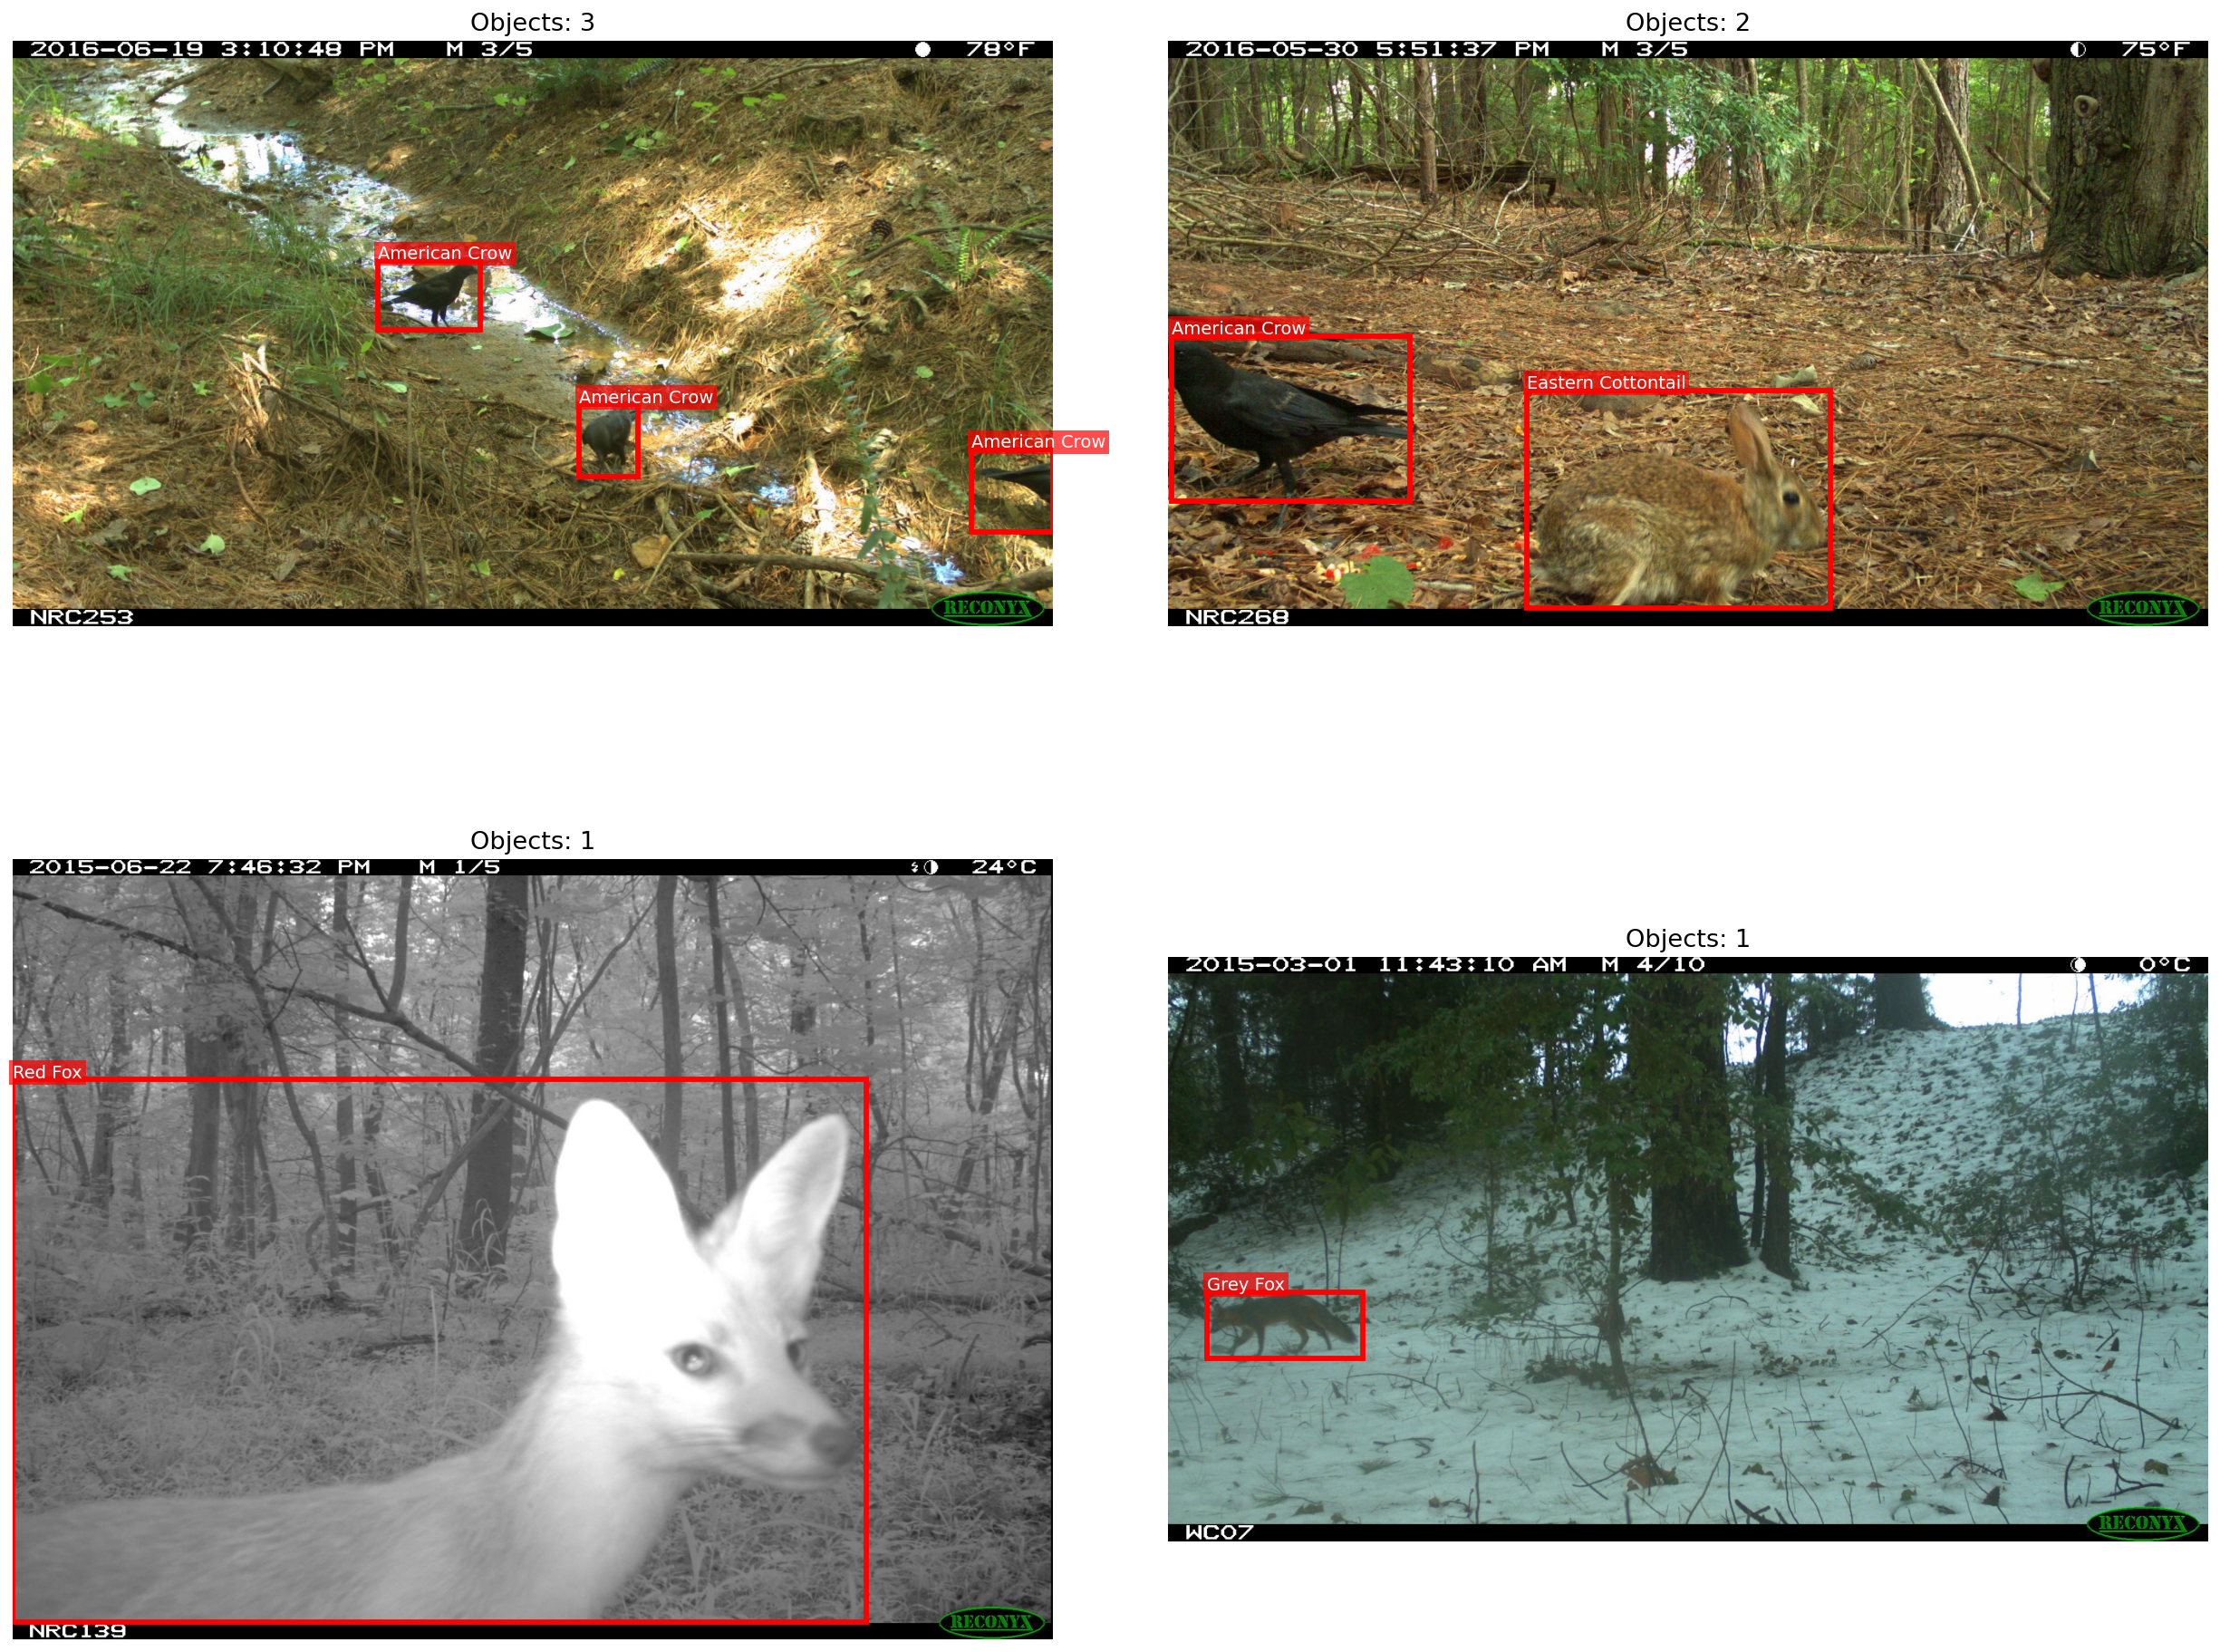

In [52]:
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

def resolve_image_path(image_record):
    file_name = image_record.get("file_name") or image_record.get("path") or image_record.get("image_path")
    if not file_name:
        return None

    candidates = [
        IMAGE_DIR / file_name,
        DATASET_DIR / file_name,
        Path(file_name),
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


if not image_records:
    print("No image records are available yet.")
    print("TODO: confirm the ENA24 annotation structure and local paths.")
else:
    random.seed(2137 * 2137)

    images_with_boxes = [img for img in image_records if image_id_to_annotations.get(img.get("id"))]
    multi_object_images = [img for img in images_with_boxes if len(image_id_to_annotations.get(img.get("id"), [])) > 1]
    single_object_images = [img for img in images_with_boxes if len(image_id_to_annotations.get(img.get("id"), [])) == 1]

    selected_images = []
    if multi_object_images:
        selected_images.extend(random.sample(multi_object_images, k=min(2, len(multi_object_images))))
    if single_object_images:
        remaining_slots = max(0, 4 - len(selected_images))
        selected_images.extend(random.sample(single_object_images, k=min(remaining_slots, len(single_object_images))))

    if len(selected_images) < 4 and images_with_boxes:
        remaining_slots = 4 - len(selected_images)
        remaining_candidates = [img for img in images_with_boxes if img not in selected_images]
        if remaining_candidates:
            selected_images.extend(random.sample(remaining_candidates, k=min(remaining_slots, len(remaining_candidates))))

    selected_images = selected_images[:4]

    if not selected_images:
        print("No suitable sample images were selected.")
    else:
        ncols = min(2, len(selected_images))
        nrows = (len(selected_images) + ncols - 1) // ncols

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(9 * ncols, 8 * nrows),
            dpi=140,
        )

        if hasattr(axes, "ravel"):
            axes = list(axes.ravel())
        else:
            axes = [axes]

        for ax, image_record in zip(axes, selected_images):
            image_path = resolve_image_path(image_record)
            if image_path is None:
                ax.text(0.5, 0.5, "Image file not found", ha="center", va="center")
                ax.axis("off")
                continue

            image = Image.open(image_path)
            ax.imshow(image)
            ax.axis("off")

            annotations = image_id_to_annotations.get(image_record.get("id"), [])
            ax.set_title(f"Objects: {len(annotations)}", fontsize=14)

            for annotation in annotations:
                bbox = annotation.get("bbox")
                if not bbox or len(bbox) != 4:
                    continue

                x, y, w, h = bbox
                rect = Rectangle((x, y), w, h, linewidth=3, edgecolor="red", facecolor="none")
                ax.add_patch(rect)

                category_id = annotation.get("category_id")
                label = category_id_to_name.get(category_id, str(category_id)) if category_id is not None else "animal"
                ax.text(
                    x,
                    max(0, y - 4),
                    label,
                    color="white",
                    fontsize=10,
                    bbox={"facecolor": "red", "alpha": 0.7, "pad": 2, "edgecolor": "none"},
                )

        for ax in axes[len(selected_images):]:
            ax.axis("off")

        plt.tight_layout(pad=2.5)
        plt.show()

## Main Challenges

Camera trap object detection is challenging because:
- some images may contain **multiple animals**, requiring several correct detections,
- animals may be small, distant, partially visible, or occluded,
- lighting conditions vary strongly, including daylight and night-time infrared imagery,
- motion blur and background clutter can make localization difficult.

## Proposed Approach (???)

At a high level, the plan could be to:
- choose one pre-trained detector as the **baseline**,
- adapt it for animal detection in camera trap images,
- use the baseline as the main reference point for later experiments,
- test whether simple changes can improve performance over the baseline.

## Possible Baseline Options

### Trivial or heuristic baseline

A very simple baseline could use fixed or random bounding boxes, or a naive heuristic such as always predicting one box near the image center.

### Classical computer vision baseline

Another option is a more traditional pipeline, for example a **sliding-window** approach combined with a classifier built on hand-crafted visual features.

### Pretrained detector with fine-tuning

The most practical baseline is likely to start from a detector pretrained on a large benchmark dataset and then fine-tune it on ENA24.

Possible candidates:
- **YOLO**: fast and widely used; a strong practical baseline when efficiency matters.
- **Faster R-CNN**: a two-stage detector that is often considered a strong reference model for detection quality.
- **SSD**: a simpler one-stage detector that can be treated as a lighter alternative.

## Commonly used metrics for object detection problems

We need to measure both **whether the model finds the animal** and **how accurately it localizes it**.

### IoU (Intersection over Union)

IoU measures how well a predicted bounding box overlaps with the ground-truth box. A higher IoU means that the predicted location is closer to the true object location.

### Precision and Recall in Detection

In the detection setting:
- **precision** reflects how many predicted detections are actually correct,
- **recall** reflects how many real animal instances were successfully detected.

This matters because a model may produce too many false alarms or miss many animals.

### mAP (mean Average Precision)

mAP is a standard summary metric for object detection. Intuitively, it combines localization quality and detection quality into one overall measure, making it more informative than a single image-level score.

### maybe F1 ???
Balance between precision i recall

## Possible extensions:
- Adding to dataset images with humans or empty images (without any animal)
- Classification of detected region into species categories